In [52]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing Liblary
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier


In [53]:
df = pd.read_csv('../1.FIFA Transfer Market Analytics/fifa_player_performance_market_value_CLEANED.csv')
df_x = df.drop(columns=['transfer_risk_level'])
df_y = df['transfer_risk_level']
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

In [54]:
feature_numerik = ['age','overall_rating', 'potential_rating', 'matches_played', 'goals',
                    'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left']
feature_nominal= ['nationality', 'club', 'position']
feature_ordinal = ['injury_prone']

atributes_ordinal = [
    ['No', 'Yes'],             # 'injury_prone'  
    # ['Low', 'Medium', 'High']  # 'transfer_risk_level' 
]

In [55]:
preprocessor = ColumnTransformer([
    ('numerik_sclaer',StandardScaler(),feature_numerik),
    ('nominal_encoding',OneHotEncoder(handle_unknown='ignore',sparse_output=False),feature_nominal),
    ('ordinal_encoding',OrdinalEncoder(categories=atributes_ordinal,handle_unknown='use_encoded_value',unknown_value=-1),feature_ordinal)
])

In [56]:
voting_model = VotingClassifier(estimators=[
    ('logistic', LogisticRegression(random_state=42)),
    ('randomForest', RandomForestClassifier(max_depth=2, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('xgboost', XGBClassifier(random_state=42)), # Diperbaiki typo 'xgboos'
    ('adaBoost', AdaBoostClassifier(random_state=42))
],voting='soft'
)


In [57]:
model_classificationSelection = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('voting_model',voting_model)
])

model_classificationSelection.fit(X_train,y_train)
result = model_classificationSelection.predict(X_test)

======= METRIK EVALUASI MODEL =======
Accuracy  : 0.4125
Precision : 0.3546
Recall    : 0.4125
F1-Score  : 0.3669

Classification Report Detail:
              precision    recall  f1-score   support

        High       0.10      0.01      0.02       102
         Low       0.44      0.65      0.52       251
      Medium       0.38      0.33      0.35       207

    accuracy                           0.41       560
   macro avg       0.31      0.33      0.30       560
weighted avg       0.35      0.41      0.37       560

Menampilkan Confusion Matrix...


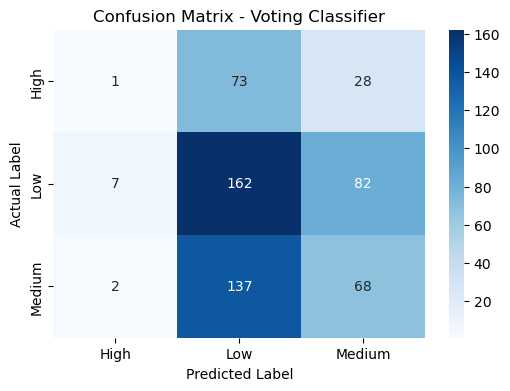

In [58]:

# 1. Menghitung Skor Dasar
accuracy = accuracy_score(y_test, result)
# Menggunakan average='weighted' atau 'macro' jika dataset kamu memiliki lebih dari 2 kelas (multiclass)
precision = precision_score(y_test, result, average='weighted', zero_division=0)
recall = recall_score(y_test, result, average='weighted', zero_division=0)
f1 = f1_score(y_test, result, average='weighted', zero_division=0)

print("======= METRIK EVALUASI MODEL =======")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=====================================\n")

# 2. Menampilkan Classification Report Lengkap (Per Kelas)
print("Classification Report Detail:")
print(classification_report(y_test, result, zero_division=0))

# 3. Membuat Visualisasi Confusion Matrix
print("Menampilkan Confusion Matrix...")
cm = confusion_matrix(y_test, result)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_classificationSelection.classes_, 
            yticklabels=model_classificationSelection.classes_)
plt.title('Confusion Matrix - Voting Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()